In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("✅ Libraries loaded")


✅ Libraries loaded


In [13]:
import os

# Make sure we're in the right directory
os.chdir(r'C:\urban-mobility-intelligence')

# Create folders if they don't exist
os.makedirs('dashboard', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

print(f"✅ Working directory: {os.getcwd()}")
print(f"✅ Folders ready")

✅ Working directory: C:\urban-mobility-intelligence
✅ Folders ready


In [7]:
from pathlib import Path

# Resolve the repository root so data loads correctly from any notebook working directory
base_dir = Path.cwd()
while not (base_dir / 'data').exists() and base_dir != base_dir.parent:
    base_dir = base_dir.parent

# Load the CSVs you saved from BigQuery
demand = pd.read_csv(base_dir / 'data' / 'demand_by_hour.csv.csv')
locations = pd.read_csv(base_dir / 'data' / 'location_revenue.csv.csv')
segments = pd.read_csv(base_dir / 'data' / 'trip_segmentation.csv.csv')

# Day names mapping
day_names = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
demand['day_name'] = demand['day_of_week'].map(day_names)

print("✅ Data loaded")
print(f"Demand shape: {demand.shape}")
print(f"Locations shape: {locations.shape}")
print(f"Segments shape: {segments.shape}")

✅ Data loaded
Demand shape: (168, 7)
Locations shape: (50, 6)
Segments shape: (20, 8)


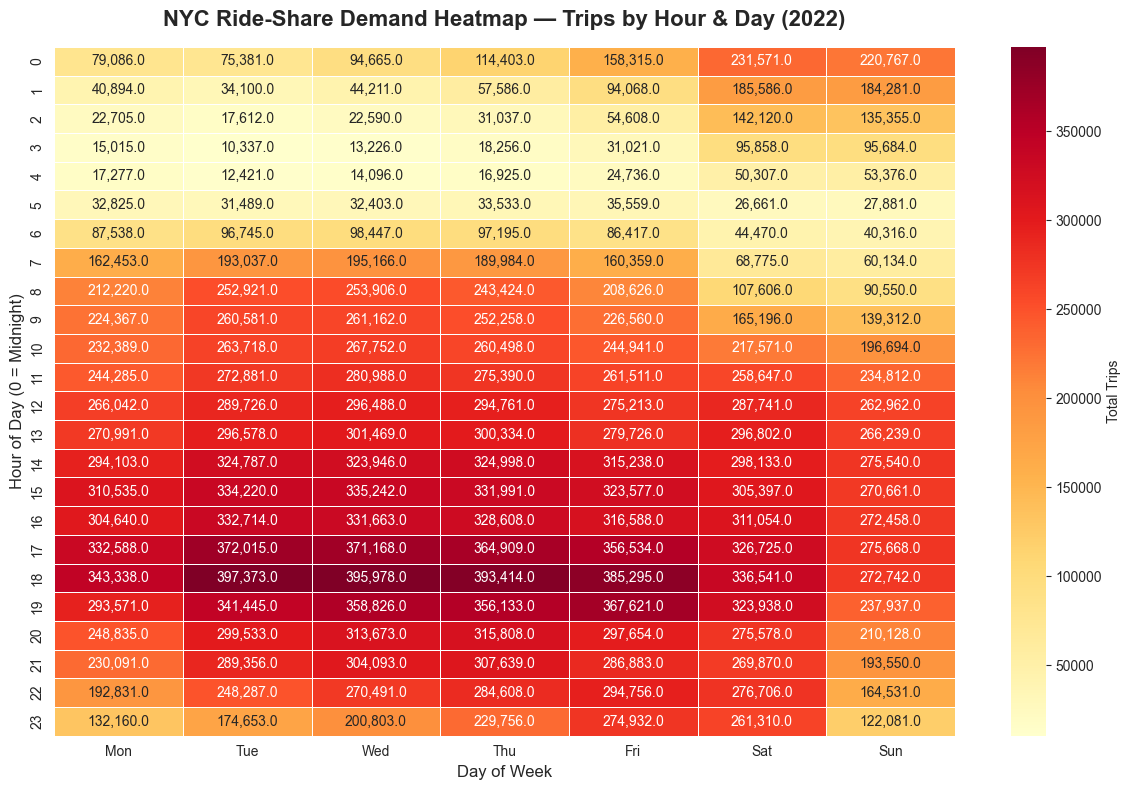

✅ Heatmap saved!


In [9]:
# Pivot for heatmap
pivot = demand.pivot_table(
    index='hour_of_day',
    columns='day_name',
    values='total_trips'
)

# Reorder days
pivot = pivot[['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    fmt=',',
    annot=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Total Trips'}
)

ax.set_title('NYC Ride-Share Demand Heatmap — Trips by Hour & Day (2022)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Hour of Day (0 = Midnight)', fontsize=12)

output_dir = base_dir / 'dashboard'
output_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(output_dir / 'demand_heatmap.png', dpi=150, bbox_inches='tight')

plt.show()
print("✅ Heatmap saved!")

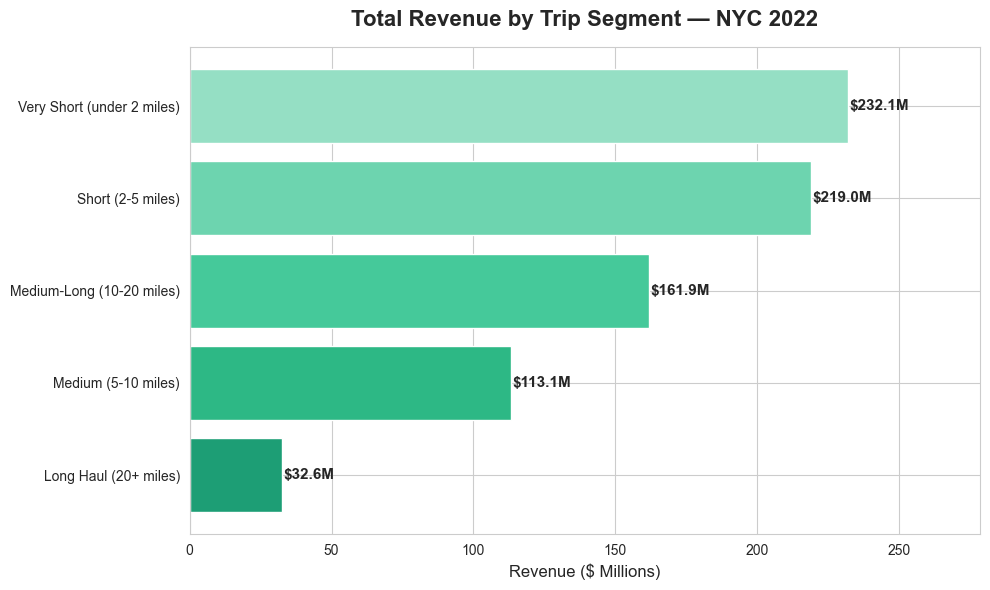

✅ Revenue chart saved!


In [10]:
# Group by trip segment
seg_rev = segments.groupby('trip_segment')['total_revenue'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D9E75','#2DB885','#45C99A','#6DD4AF','#95DFC4']
bars = ax.barh(seg_rev.index, seg_rev.values / 1e6, color=colors)

# Add value labels
for bar, val in zip(bars, seg_rev.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=11, fontweight='bold')

ax.set_title('Total Revenue by Trip Segment — NYC 2022',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Revenue ($ Millions)', fontsize=12)
ax.set_xlim(0, seg_rev.max()/1e6 * 1.2)

output_dir = base_dir / 'dashboard'
output_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(output_dir / 'revenue_by_segment.png', dpi=150, bbox_inches='tight')

plt.show()
print("✅ Revenue chart saved!")

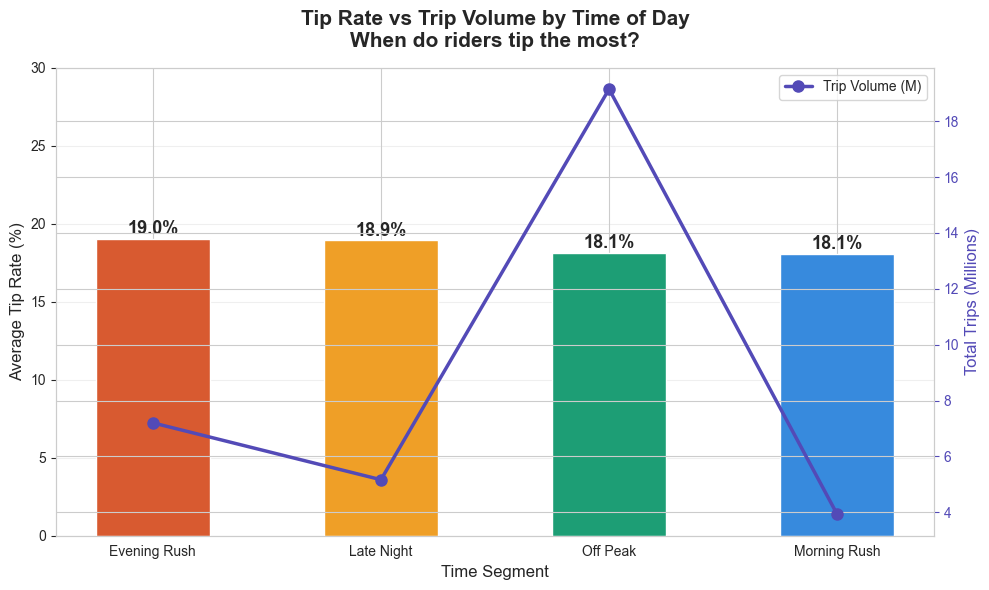

✅ Tip rate chart saved!


In [14]:
# Tip rate by time of day
tip_by_time = segments.groupby('time_segment').agg(
    avg_tip_rate=('tip_rate_pct', 'mean'),
    total_trips=('total_trips', 'sum')
).reset_index().sort_values('avg_tip_rate', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))

colors = ['#D85A30','#EF9F27','#1D9E75','#378ADD']
bars = ax1.bar(tip_by_time['time_segment'],
               tip_by_time['avg_tip_rate'],
               color=colors, width=0.5, zorder=3)

# Add value labels on bars
for bar, val in zip(bars, tip_by_time['avg_tip_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Overlay trip volume as line
ax2 = ax1.twinx()
ax2.plot(tip_by_time['time_segment'],
         tip_by_time['total_trips']/1e6,
         color='#534AB7', marker='o', linewidth=2.5,
         markersize=8, label='Trip Volume (M)', zorder=4)
ax2.set_ylabel('Total Trips (Millions)', fontsize=12, color='#534AB7')
ax2.tick_params(axis='y', colors='#534AB7')

ax1.set_title('Tip Rate vs Trip Volume by Time of Day\nWhen do riders tip the most?',
              fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Time Segment', fontsize=12)
ax1.set_ylabel('Average Tip Rate (%)', fontsize=12)
ax1.set_ylim(0, 30)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('dashboard/tip_rate_by_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tip rate chart saved!")